# Accessing Text

## Accessing Text corpus in NLTK

A text corpus is a large body of text. Many corpora are designed to contain a careful balance of material in one or more genres.

NLTK contains many text corpora, the complete list is available [here](https://www.nltk.org/nltk_data/)

### Gutenberg Corpus


In [ ]:
import nltk

In [ ]:
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


True

In [ ]:
nltk.download('brown')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


True

In [ ]:
#simple tokenizer
#sent = input("Enter a sentence: ")
sent = "The boy ate an apple from the city"
sent = sent.lower()
print(sent)
tokens = sent.split()
print("Tokens:",tokens)
vocab = set(tokens)
print("Voacb:", vocab)

the boy ate an apple from the city
Tokens: ['the', 'boy', 'ate', 'an', 'apple', 'from', 'the', 'city']
Voacb: {'the', 'boy', 'an', 'from', 'apple', 'ate', 'city'}


In [ ]:
import nltk
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [ ]:
from nltk.corpus import gutenberg
emma = gutenberg.words('austen-emma.txt')
len(emma)

192427

In [ ]:
from nltk.corpus import gutenberg
emma = gutenberg.words('bible-kjv.txt')
len(emma)

1010654

In [ ]:
emma[:10]

['[', 'The', 'King', 'James', 'Bible', ']', 'The', 'Old', 'Testament', 'of']

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
for fileid in gutenberg.fileids():
    num_chars = len(gutenberg.raw(fileid))
    num_words = len(gutenberg.words(fileid))
    num_sents = len(gutenberg.sents(fileid))
    num_vocab = len(set(w.lower() for w in gutenberg.words(fileid)))
    print(round(num_chars/num_words), round(num_words/num_sents), round(num_words/num_vocab), fileid)

5 25 26 austen-emma.txt
5 26 17 austen-persuasion.txt
5 28 22 austen-sense.txt
4 34 79 bible-kjv.txt
5 19 5 blake-poems.txt
4 19 14 bryant-stories.txt
4 18 12 burgess-busterbrown.txt
4 20 13 carroll-alice.txt
5 20 12 chesterton-ball.txt
5 23 11 chesterton-brown.txt
5 18 11 chesterton-thursday.txt
4 21 25 edgeworth-parents.txt
5 26 15 melville-moby_dick.txt
5 52 11 milton-paradise.txt
4 12 9 shakespeare-caesar.txt
4 12 8 shakespeare-hamlet.txt
4 12 7 shakespeare-macbeth.txt
5 36 12 whitman-leaves.txt


### Brown Corpus

In [ ]:
from nltk.corpus import brown

In [ ]:
brown.categories()

NameError: name 'brown' is not defined

In [ ]:
brown.words(categories='news')

['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', ...]

In [ ]:
genres = ['news', 'religion', 'hobbies', 'science_fiction', 'romance', 'humor']
modals = ['can', 'could', 'may', 'might', 'must', 'will']

cfd = nltk.ConditionalFreqDist(
    (genre, word)
    for genre in brown.categories()
    for word in brown.words(categories=genre))

cfd.tabulate(conditions=genres, samples=modals)

                  can could   may might  must  will 
           news    93    86    66    38    50   389 
       religion    82    59    78    12    54    71 
        hobbies   268    58   131    22    83   264 
science_fiction    16    49     4    12     8    16 
        romance    74   193    11    51    45    43 
          humor    16    30     8     8     9    13 


# Try it Now
Find the conditional freq distibution of modal verbs in  the following 3 works:

* 'shakespeare-caesar.txt',
* 'shakespeare-hamlet.txt',
* 'shakespeare-macbeth.txt'


 modals = ['can', 'could', 'may', 'might', 'must', 'will']


In [ ]:

modals = ['can', 'could', 'may', 'might', 'must', 'will']

genres = ['shakespeare-caesar.txt','shakespeare-hamlet.txt','shakespeare-macbeth.txt']


cfd = nltk.ConditionalFreqDist(
    (genre, word)
    for genre in genres
    for word in gutenberg.words(genre))

cfd.tabulate(conditions=genres, samples=modals)

                          can could   may might  must  will 
 shakespeare-caesar.txt    16    18    35    12    30   129 
 shakespeare-hamlet.txt    33    26    56    28    53   131 
shakespeare-macbeth.txt    21    15    30     5    33    62 


## Accessing text from Web

In [ ]:
from urllib import request
url = "https://en.wikipedia.org/wiki/Natural_language_processing"
response = request.urlopen(url)
raw = response.read().decode('utf8')
raw[:500]


'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vect'

In [ ]:
from bs4 import BeautifulSoup
text = BeautifulSoup(raw, 'html.parser').get_text()
text=text.replace('\n','')
text=text.replace('\t','')
text=text.strip()
text[:500]

'Natural language processing - WikipediaJump to contentMain menuMain menumove to sidebarhideNavigationMain pageContentsCurrent eventsRandom articleAbout WikipediaContact usContributeHelpLearn to editCommunity portalRecent changesUpload fileSearchSearchAppearanceDonateCreate accountLog inPersonal toolsDonate Create account Log inPages for logged out editors learn moreContributionsTalkContentsmove to sidebarhide(Top)1HistoryToggle History subsection1.1Symbolic NLP (1950s – early 1990s)1.2Statistica'

# Try it Now:
Read a url and give the analysis : including top ten frequent characters, top 10 frequent words. You can convert everything to lowercase.


## Reading a text file

In [ ]:
text = open('/content/drive/MyDrive/N-FAB-Materials-Manu/sample.txt').read()
text[:40]

'Natural language processing (NLP) is an '

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
len(text)

786

## Processing the Raw Text

### String Operations

In [ ]:
s = "Welcome to NLP-2025"
print("Number of characters: ",len(s))

Number of characters:  19


In [ ]:
s[0]

'W'

In [ ]:
s[1:10:2] # first 10 characters

'ecm o'

In [ ]:
s[:-2]

'Welcome to NLP-20'

In [ ]:
s[-2:]

'25'

In [ ]:
s.count('l')

1

In [ ]:
s.split() #split based on space

['Welcome', 'to', 'NLP-2025']

In [ ]:
[ch for ch in s if ch.isalpha()]

['W', 'e', 'l', 'c', 'o', 'm', 'e', 't', 'o', 'N', 'L', 'P']

In [ ]:
s.lower()

'welcome to nlp-2025'

In [ ]:
s.upper()

'WELCOME TO NLP-2025'

In [ ]:
s.title()

'Welcome To Nlp-2025'

In [ ]:
s.replace('2025','23')

'Welcome to NLP-23'

### Tokens

In [ ]:
from nltk.tokenize import sent_tokenize
from nltk import word_tokenize
from nltk.tokenize import wordpunct_tokenize

In [ ]:
text = open('/content/drive/MyDrive/N-FAB-Materials-Manu/austen-emma.txt').read()
text[:300]

'[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCHAPTER I\n\n\nEmma Woodhouse, handsome, clever, and rich, with a comfortable home\nand happy disposition, seemed to unite some of the best blessings\nof existence; and had lived nearly twenty-one years in the world\nwith very little to distress or vex her.\n\nShe was t'

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
sentences = sent_tokenize(text)
sentences[:10]

['[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCHAPTER I\n\n\nEmma Woodhouse, handsome, clever, and rich, with a comfortable home\nand happy disposition, seemed to unite some of the best blessings\nof existence; and had lived nearly twenty-one years in the world\nwith very little to distress or vex her.',
 "She was the youngest of the two daughters of a most affectionate,\nindulgent father; and had, in consequence of her sister's marriage,\nbeen mistress of his house from a very early period.",
 'Her mother\nhad died too long ago for her to have more than an indistinct\nremembrance of her caresses; and her place had been supplied\nby an excellent woman as governess, who had fallen little short\nof a mother in affection.',
 "Sixteen years had Miss Taylor been in Mr. Woodhouse's family,\nless as a governess than a friend, very fond of both daughters,\nbut particularly of Emma.",
 'Between _them_ it was more the intimacy\nof sisters.',
 "Even before Miss Taylor had ceased to hold the nominal

In [ ]:
tokens = word_tokenize(text)
print(tokens[:100])

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.', 'She', 'was', 'the', 'youngest', 'of', 'the', 'two', 'daughters', 'of', 'a', 'most', 'affectionate', ',', 'indulgent', 'father', ';', 'and', 'had', ',', 'in', 'consequence', 'of', 'her', 'sister', "'s", 'marriage', ',', 'been', 'mistress', 'of', 'his', 'house', 'from', 'a', 'very', 'early', 'period', '.', 'Her', 'mother', 'had', 'died']


In [ ]:
s= "Could you please tell me Ann's phone number?"
print(wordpunct_tokenize(s))
print(word_tokenize(s))

['Could', 'you', 'please', 'tell', 'me', 'Ann', "'", 's', 'phone', 'number', '?']
['Could', 'you', 'please', 'tell', 'me', 'Ann', "'s", 'phone', 'number', '?']


In [ ]:
s= "I bought apple, mango, and orange. Is it from U.S.A"
print(wordpunct_tokenize(s))
print(word_tokenize(s))

['I', 'bought', 'apple', ',', 'mango', ',', 'and', 'orange', '.', 'Is', 'it', 'from', 'U', '.', 'S', '.', 'A']
['I', 'bought', 'apple', ',', 'mango', ',', 'and', 'orange', '.', 'Is', 'it', 'from', 'U.S.A']


### Types and Tokens

In [ ]:
text = "The cat chased the mouse, and the mouse escaped"

tokens = word_tokenize(text)
print(tokens)


['The', 'cat', 'chased', 'the', 'mouse', ',', 'and', 'the', 'mouse', 'escaped']


In [ ]:
types = set(tokens)
types

{',', 'The', 'and', 'cat', 'chased', 'escaped', 'mouse', 'the'}

In [ ]:
tokens = word_tokenize(text.lower())
types = set(tokens)
print(types)

{'and', 'cat', 'chased', 'escaped', 'the', 'mouse', ','}


### Stopwords

In [ ]:
from nltk.corpus import stopwords

nltk.download('stopwords')
print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
sent = "The boy ate an apple which was on the table"
tokens = word_tokenize(sent)
clean_tokens= [tok for tok in tokens if tok not in stopwords.words('english')]
print("Before:", tokens, len(tokens))
print("After:",clean_tokens, len(clean_tokens))

Before: ['The', 'boy', 'ate', 'an', 'apple', 'which', 'was', 'on', 'the', 'table'] 10
After: ['The', 'boy', 'ate', 'apple', 'table'] 5


### Normalizing Text

#### Stemming

In [ ]:
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

ps = PorterStemmer()

words = ["program", "programs", "programmer", "programming", "programmers"]

for w in words:
    print(w,"-->", ps.stem(w))

program --> program
programs --> program
programmer --> programm
programming --> program
programmers --> programm


In [ ]:
ps.stem("computing")

'comput'

#### Lemmatization

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
orginal = "Running and jumped are different verb forms of the word run and jump, respectively"

wnl = nltk.WordNetLemmatizer()

tokens = word_tokenize(orginal)
[wnl.lemmatize(t) for t in tokens]

['Running',
 'and',
 'jumped',
 'are',
 'different',
 'verb',
 'form',
 'of',
 'the',
 'word',
 'run',
 'and',
 'jump',
 ',',
 'respectively']

In [ ]:
[ps.stem(w) for w in tokens]

['run',
 'and',
 'jump',
 'are',
 'differ',
 'verb',
 'form',
 'of',
 'the',
 'word',
 'run',
 'and',
 'jump',
 ',',
 'respect']

In [ ]:
wnl.lemmatize("playing")

'playing'

### EDA for Text

In [ ]:
#open text
text = open('/content/drive/MyDrive/N-FAB-Materials-Manu/austen-emma.txt').read()

#change all letter to lowercase
text = text.lower()

#tokenize
tokens = word_tokenize(text)
print("Tokens: ", len(tokens))

#types
types = set(tokens)
print("Types: ", len(types))


Tokens:  191781
Types:  7944


In [ ]:
#Frequency distribution
frequency_dist = nltk.FreqDist(tokens)
sorted(frequency_dist,key=frequency_dist.__getitem__, reverse=True)[0:30]

[',',
 '.',
 'the',
 'to',
 'and',
 'of',
 'i',
 'a',
 '--',
 'it',
 "''",
 'her',
 'was',
 ';',
 'she',
 'not',
 'in',
 'be',
 'you',
 'he',
 'that',
 '``',
 'had',
 'but',
 'as',
 'for',
 'have',
 'is',
 'with',
 'very']

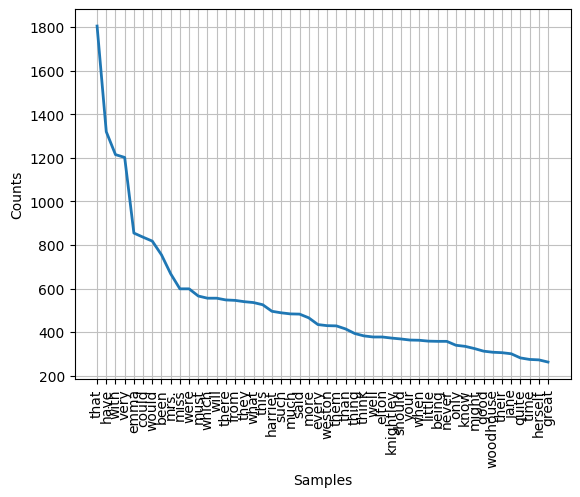

<Axes: xlabel='Samples', ylabel='Counts'>

In [ ]:
%matplotlib inline
large_words = dict([(k,v) for k,v in frequency_dist.items() if len(k)>3])
frequency_dist = nltk.FreqDist(large_words)
frequency_dist.plot(50,cumulative=False)

In [ ]:
#stopword removal
clean_tokens =[tok for tok in tokens if tok not in stopwords.words('english')]
frequency_dist = nltk.FreqDist(clean_tokens)
sorted(frequency_dist,key=frequency_dist.__getitem__, reverse=True)[0:30]

[',',
 '.',
 '--',
 "''",
 ';',
 '``',
 'mr.',
 '!',
 "'s",
 'emma',
 'could',
 'would',
 'mrs.',
 '?',
 'miss',
 'must',
 'harriet',
 'much',
 'said',
 'one',
 'every',
 'weston',
 'thing',
 'think',
 'well',
 'elton',
 'knightley',
 'little',
 'never',
 'know']

In [ ]:
#Remove punctuations
from nltk.tokenize import RegexpTokenizer
sample = "Wow! we are here.."
tokenizer = RegexpTokenizer(r'\w+')
tokens = tokenizer.tokenize(sample)
tokens


['Wow', 'we', 'are', 'here']

In [ ]:
tokenizer = RegexpTokenizer(r'\w+')
tokens = tokenizer.tokenize(text)
tokens = [tok for tok in tokens if tok not in stopwords.words('english')]
frequency_dist = nltk.FreqDist(tokens)
sorted(frequency_dist,key=frequency_dist.__getitem__, reverse=True)[0:30]

['mr',
 'emma',
 'could',
 'would',
 'mrs',
 'miss',
 'must',
 'harriet',
 'much',
 'said',
 'one',
 'weston',
 'every',
 'well',
 'thing',
 'knightley',
 'elton',
 'think',
 'little',
 'never',
 'good',
 'know',
 'might',
 'woodhouse',
 'say',
 'jane',
 'quite',
 'time',
 'great',
 'nothing']

### Type to Token Ratio (TTR)

In [ ]:
types = set(tokens)

ttr = len(tokens)/len(types)
ttr

10.320280701754386

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud



In [ ]:
wc = WordCloud().generate_from_frequencies(frequency_dist)


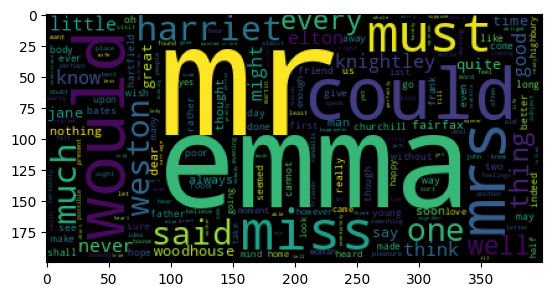

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(wc)